# Bayesian Statistics

## Introduction

Bayesian statistics is a probabilistic approach to inference, where beliefs are updated as new evidence becomes available. The core idea is encapsulated in [**Bayes' Theorem**](https://en.wikipedia.org/wiki/Bayes%27_theorem), which relates prior knowledge to new data.

Bayes' Theorem:

```math

 P(A|B) = \frac{P(B|A) P(A)}{P(B)} 

```

where:
- *P(A)* is the **prior probability**, the belief before seeing any evidence.
- *P(B|A)* is the **conditional probability**, the probability of observing the evidence given the hypothesis.
- *P(B)* is the **marginal probability**, a normalizing constant ensuring valid probabilities.
- *P(A|B)* is the **posterior probability**, the updated belief after considering the evidence.

### The Bayes' Theorem Derivation 

From our basic probability theory we know that the conditional probabilities are normalized joint probability. 


```math 

P(A \mid B) = \frac{P(A \cap B)}{P(B)} \\ \\ \\ \\


P(B \mid A) = \frac{P(B \cap A)}{P(A)}

```

Since the left sides of these two equations are equal, we get the following:

```math 

P(A \cap B) = P(B \cap A)\\ \\ \\ \\


P(B) P(A \mid B) = P(A) P(B \mid A) 


```

Rearrangement of the above equation results in the Bayes' Theorem. 

```math 


P(A \mid B) = \frac{P(B \mid A) P(A)}{P(B)} 


```

### Where

Bayesian statistics has applications from medical cases to climate and financial modeling. These applications usually are part of one of the following cases:

- Hypothesis testing and probability theory 
- Uncertainty assessment 
- Classification ([Naive Bayes](https://en.wikipedia.org/wiki/Naive_Bayes_classifier))
- Regression 

## Hypothesis testing and probability theory

We have a classroom with total of 40 students with different sport preferences. 

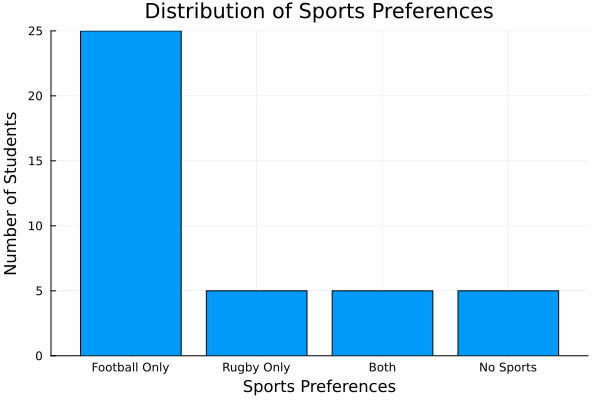

In [34]:
using ACS # Load the package

labels = ["Football Only", "Rugby Only", "Both", "No Sports"]
values = [25, 5, 5, 5]  # Derived from 30 football, 10 rugby (including both), and 5 no sports

# Plot
bar(labels, values, xlabel="Sports Preferences", ylabel="Number of Students", title="Distribution of Sports Preferences", legend=false)

### E1:
Compute the following probabilities based on the student sports example:
1. *P(Football | Rugby)* - Probability that a student likes football given they like rugby.
2. *P(Rugby | Football)* - Probability that a student likes rugby given they like football.
3. *P(No Sports | Football)* - Probability that a student does not like sports given they like football.
4. *P(Football \cap Rugby)* - Joint probability of liking both sports.

> Answer to E1: 
>
> students = 40
> 
> football = 30/students
> 
> rugby = 10/students
> 
> no_sports = 5/students
> 
> both_sports = 5/students
> 

In [35]:
students = 40
football = 30
rugby = 10
both_sports = 5
no_sports = 5

p_football_given_rugby = both_sports / rugby
p_rugby_given_football = both_sports / football
p_no_sports_given_football = no_sports / football
p_joint = both_sports/ students

println("P(Football | Rugby): ", p_football_given_rugby)
println("P(Rugby | Football): ", p_rugby_given_football)
println("P(No Sports | Football): ", p_no_sports_given_football)
println("P(Football ∩ Rugby): ", p_joint)

P(Football | Rugby): 0.5
P(Rugby | Football): 0.16666666666666666
P(No Sports | Football): 0.16666666666666666
P(Football ∩ Rugby): 0.125


### E2: 

A disease affects 1% of the population. A test has:
- 90% true positive rate
- 8% false positive rate

Compute *P(Sick | Positive Test)*.

In [36]:
sick = 0.01  # Prior
test_positive_given_sick = 0.9 # Sensitivity    
false_positive = 0.08 # False positive rate

# Compute posterior
marginal = (sick * test_positive_given_sick) + ((1 - sick) * false_positive)
posterior = (test_positive_given_sick * sick) / marginal

println("P(Sick | Positive Test): ", posterior)

P(Sick | Positive Test): 0.10204081632653063


## Uncertainty assessment

The main objective here to try to true distribution of data based on potentially very noisy data. With high quality data, the main source of uncertainty is the random error and as a consequence there is a normal distribution of data with a certain standard deviation around the mean value. In real life with complex measurements this becomes more difficult to achieve. 

Let's simulate such a scenario: imagine you are measuring the concentration of a certain pharmaceutical in the urine samples of a clinical trial. This drug at low concentrations (i.e. < 5 ppb) does not have an effect while at high levels (i.e. > 9) could be lethal. Your previous measurements of these concentrations results in the below distribution. 

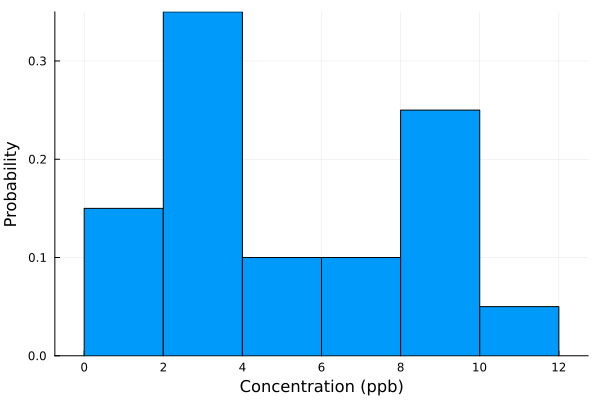

In [37]:
x = [2.11170571,4.654611177,2.058684377,9.118890998,6.482271164,1.741767743,0.423550831,3.930361297
,8.394899978,2.720184918,4.642679068,0.698396604,10.60195845,9.949609087,9.788688087,9.275078609
,3.71104968,3.048191598,7.131314198,2.696493503]

histogram(x,bins=5,normalize=:probability,label=false)
xlabel!("Concentration (ppb)")
ylabel!("Probability")

### E3:

Let's overlay a normal distribution with the mean and std of *X* on the above distribution. Is this an acceptable distribution for your data?

Hint: you can use ``Normal(mean(x),std(x))`` for that.

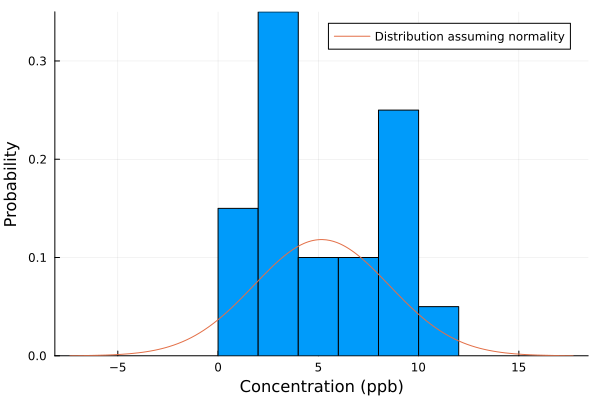

In [38]:
histogram(x,bins=5,normalize=:probability,label=false)
plot!(Normal(mean(x),std(x)),label="Distribution assuming normality")

xlabel!("Concentration (ppb)")
ylabel!("Probability")

As you can see the overlaid normal distribution is too wide and shows a very high level of uncertainty indicated by the standard deviation of the distribution. 

### E4:

Calculate the maximum likelihood estimates of the mean and the standard deviation.

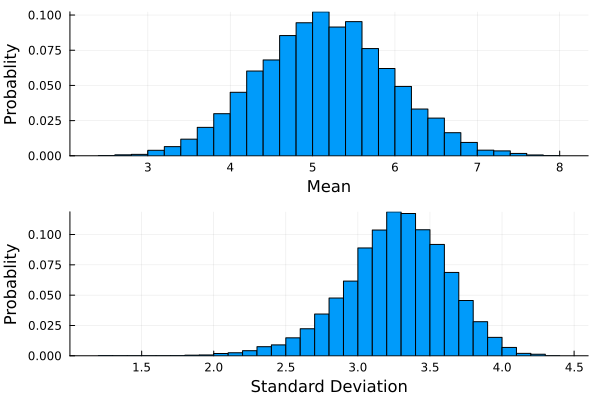

In [39]:
function r_sample(x,n,prc)
    m = zeros(n)
    st = zeros(n)

    for i =1:n
        tv1 = rand(x,Int(round(prc*length(x))))
        m[i] = mean(tv1)
        st[i] = std(tv1)

    end

    return m, st

end


n = 10000
prc = 0.85

m, st = r_sample(x,n,prc);

p1 = histogram(m,bins=30,normalize=:probability,label=false)
xlabel!("Mean")
ylabel!("Probablity")

p2 = histogram(st,bins=30,normalize=:probability,label=false)
xlabel!("Standard Deviation")
ylabel!("Probablity")   

plot(p1,p2,layout=(2,1))

As you can see, our results are very similar to what we got by simply assuming a normal distribution for our measurements.

<div class="alert alert-block alert-info">
<b>Note:</b> 
Both normality assumption and bootstrapping assume a flat or an uninformative prior. In other words all the values in the measured range have the same probability of being the true value. That's why both will result in the maximum likelihood estimates of the mean and the standard deviation.
</div>

### E5: 

Looking at you data (i.e. *X*) is there another distribution that you think could describe your data better than a normal distribution?

> Answer to E5
>
> We can use a [gamma distribution](https://en.wikipedia.org/wiki/Gamma_distribution) with apex at around 3 ppb. This distribution will become our prior distribution.
>

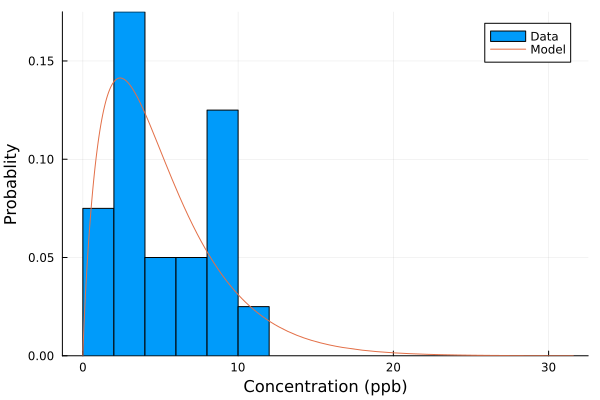

In [40]:
pri = fit_mle(Gamma,x)

histogram(x,bins=5,label="Data",normalize=true)
plot!(fit_mle(Gamma, x),label="Model")
xlabel!("Concentration (ppb)")
ylabel!("Probablity")

### E6: 

Having this distribution as our prior, we can calculate the ```P(mean|measurement)```. How would you calculate this for a case where we assume that 10.5 ppb is the true value for our measurement. 

Hint! We can take advantage of the following approximation of the Bayes' Theorem, where we assume a constant marginal probability. 

```math

P(A|B) \propto P(A|B) \times P(B)

```

> Answer to E6
>
> If we have 10.5 as our true value, we need to assume a distribution for it. The go to distribution in such cases is Normal with the assumed true value being the mean and the standard deviation of *X* being its standard deviation. Once this is done, we have everything for doing the above calculation. In other words, we need to calculate the probability of every measured value given the two distributions.
> 

In [41]:
dist = Normal(10.5,std(x))                                 # Distribution of the assumed mean
post = 1                                                          # Initialize the likelihood values
    for j = 1:length(x)

        post = post * pdf(dist,x[j]) * pdf(pri,x[j])                    # Updating the likelihood over each iteration

    end
post

2.2474435734590975e-56

As you can see, given the prior distribution, the likelihood of 10.5 being the true value is extremely small.

### E7:

Can we do these calculations for the full range of *X*? 

Hint: You can define the resolution of your calculations, as you would like to do so.

In [42]:
function uncertainty_estimate(x,pri,res)
    target = collect(range(minimum(x),maximum(x),length = res))       # Generate a set of potential mean values
    post = zeros(length(target))                                        # Generate the posterior distribution vector

    for i =1:length(target)

        dist = Normal(target[i],std(x))                                 # Distribution of the assumed mean
        tv = 1                                                          # Initialize the likelihood values
        for j = 1:length(x)

            tv = tv * pdf(dist,x[j]) * pdf(pri,x[j])                    # Updating the likelihood over each iteration

        end

        post[i] = tv


    end

    post = post ./ sum(post)                                                # Normalize the posterior distribution

    return post, target
end


res = 1000
post, target = uncertainty_estimate(x,pri,res)

([1.4933781446606886e-11, 1.6253729069632584e-11, 1.7687115637592804e-11, 1.924339914186291e-11, 2.0932800506897685e-11, 2.2766362935571736e-11, 2.4756015687610073e-11, 2.691464260744287e-11, 2.9256155739229885e-11, 3.1795574389571844e-11  …  6.367888457379762e-14, 5.785551519285487e-14, 5.255509879475791e-14, 4.7731570295973276e-14, 4.3342839680376364e-14, 3.935045646419043e-14, 3.571930181776945e-14, 3.241730612269675e-14, 2.9415189916131935e-14, 2.6686226334686128e-14], [0.423550831, 0.43373942721521525, 0.4439280234304305, 0.45411661964564565, 0.4643052158608609, 0.4744938120760761, 0.48468240829129133, 0.4948710045065065, 0.5050596007217217, 0.5152481969369369  …  10.510261084063062, 10.520449680278277, 10.530638276493493, 10.540826872708708, 10.551015468923923, 10.561204065139139, 10.571392661354354, 10.58158125756957, 10.591769853784784, 10.60195845])

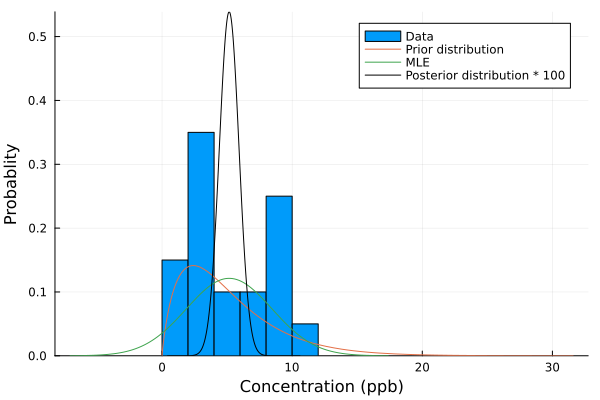

In [43]:
histogram(x,bins=5,label="Data",normalize=:probability)
plot!(fit_mle(Gamma,x),label="Prior distribution")
plot!(fit_mle(Normal, x),label="MLE")
plot!(target,10^2 .* post,label="Posterior distribution * 100",c=:black)
#plot!(fit_mle(Normal, m),label="Model")
xlabel!("Concentration (ppb)")
ylabel!("Probablity")

As expected the true value is very close to the mean, however, the uncertainty associated with it far smaller, enabling potential decision making.

## Naive Bayes classifier

Naive Bayes classifier assumes that the order of events does not have an impact on their conditional probability. Based on this assumption one could calculate the probability of two different events given a certain evidence and the one with higher probability would be considered as a true positive. This type of Bayesian statistics has been employed in different applications including your emails spam detector. 

## E8: 

Consider a spam filter that classifies emails based on the presence of certain words.

- 20% of emails are spam.
- 70% of spam emails contain the word 'lottery'.
- 5% of non-spam emails contain 'lottery'.

Let's compute:

```math 
P(Spam | Lottery) = \frac{P(Lottery | Spam) P(Spam)}{P(Lottery)}
```

In [44]:
spam = 0.2  # Prior probability of spam
word_given_spam = 0.7  # Likelihood of 'lottery' in spam
word_given_ham = 0.05  # Likelihood of 'lottery' in non-spam
ham = 1 - spam  # Non-spam probability

evidence = (spam * word_given_spam) + (ham * word_given_ham)
posterior_spam = (word_given_spam * spam) / evidence

println("Probability that an email with 'lottery' is spam: ", posterior_spam)

Probability that an email with 'lottery' is spam: 0.7777777777777777


### E9:

Now let's consider the word "friend".

- 10% of spam emails contain the word 'friend'.
- 85% of non-spam emails contain 'friend'.

Let's compute:

```math 
P(Spam | friend) = \frac{P(friend | Spam) P(Spam)}{P(friend)}
```

In [45]:
word_given_spam = 0.1  # Likelihood of 'friend' in spam
word_given_ham = 0.85  # Likelihood of 'friend' in non-spam

evidence = (spam * word_given_spam) + (ham * word_given_ham)
posterior_spam_2 = (word_given_spam * spam) / evidence

0.028571428571428574

### E10:

What if we have both words present in an email. What is the probability of ```P(Spam | friend&lottery)```?


> Answer to Ex:
>
> To calculate this posterior probability we need to multiply the two previously calculated probabilities.
> 

In [46]:
posterior_spam_3 = posterior_spam_2 * posterior_spam

0.022222222222222223

### E11: 

Now that we know the true concentration of our chemical (i.e. *X*), we would like to assess whether it could exhibit toxic effects or not. We know that the toxic effects and no-effect concentrations have the below distributions. 

```julia
tx = Normal(9.5,0.5*std(x))
n_tx = Normal(2.5,0.3*std(x))

```

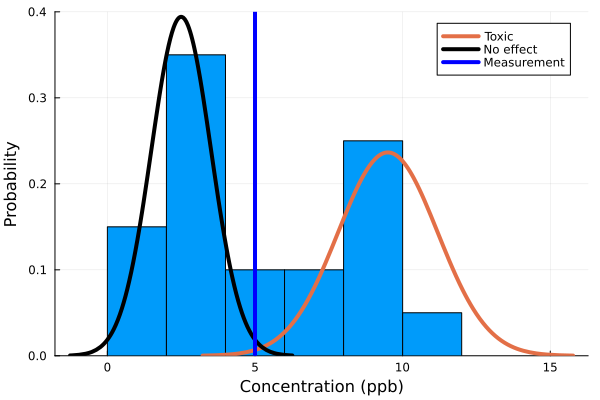

In [47]:
histogram(x,bins=5,normalize=:probability,label=false)
plot!(Normal(9.5,0.5*std(x)),label="Toxic",lw = 4)
plot!(Normal(2.5,0.3*std(x)),label="No effect",c=:black,lw = 4)
plot!([5,5],[0,0.4],label="Measurement",c=:blue,lw = 4)

xlabel!("Concentration (ppb)")
ylabel!("Probability")

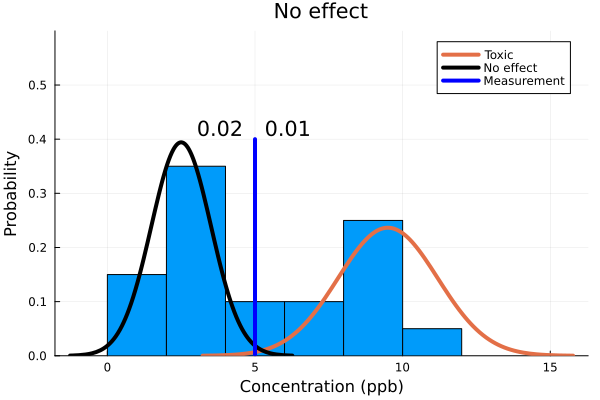

In [48]:
tx = Normal(9.5,0.5*std(x))
n_tx = Normal(2.5,0.3*std(x))

p_toxic = pdf(tx,5)
p_no_effect = pdf(n_tx,5)

ylims!(0,0.6)
annotate!(6.1,0.42,string(round(p_toxic,digits=2)))
annotate!(3.8,0.42,string(round(p_no_effect,digits=2)))
title!("No effect")

## Bayesian Regression: 

Bayesian statistics can also be used for solving regression problems. The Bayesian regression is an extension of the the uncertainty assessment, where the Bayes theorem is used to estimate the coefficients of a model starting from a flat prior for all the coefficients. The added step here is to use the sum square errors to improve the prior distribution of the coefficients. Typically these complex modeling problems are solved using a combination of Bayes theorem and Monte Carlo simulations 